In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    GlobalAveragePooling2D,
    Dense,
    Dropout,
    Lambda
)

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)


In [ ]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Training Images Shape:", x_train.shape)
print("Training Labels Shape:", y_train.shape)

print("Testing Images Shape:", x_test.shape)
print("Testing Labels Shape:", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2716s 16us/step
Training Images Shape: (50000, 32, 32, 3)
Training Labels Shape: (50000, 1)
Testing Images Shape: (10000, 32, 32, 3)
Testing Labels Shape: (10000, 1)


In [ ]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [ ]:
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

In [ ]:
class_names = [
    "Airplane",
    "Automobile",
    "Bird",
    "Cat",
    "Deer",
    "Dog",
    "Frog",
    "Horse",
    "Ship",
    "Truck"
]

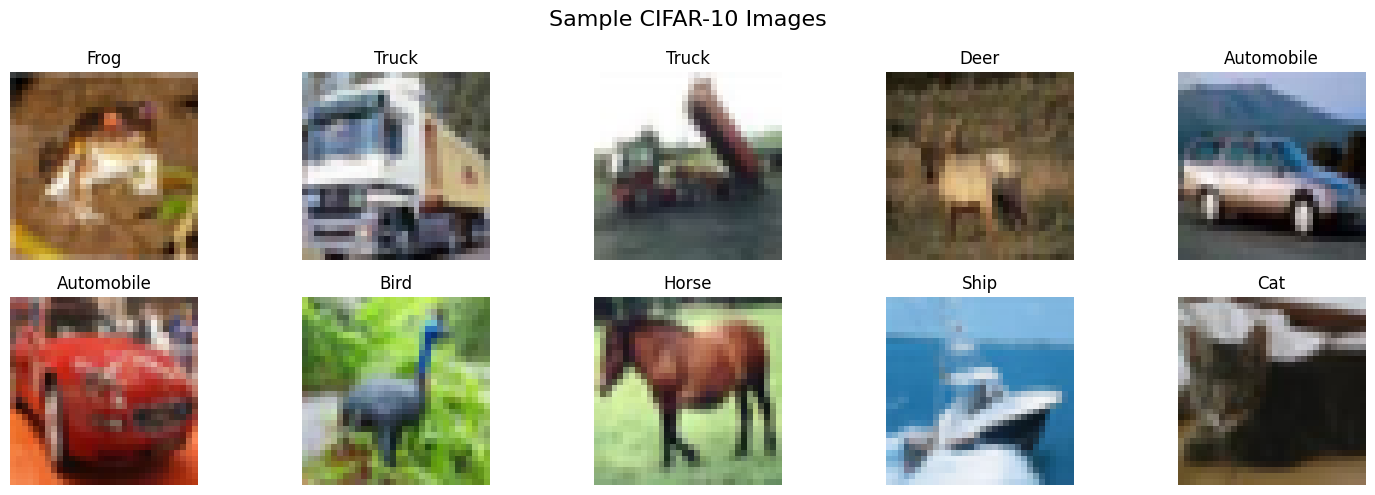

In [ ]:
plt.figure(figsize=(15, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.suptitle("Sample CIFAR-10 Images", fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
IMG_SIZE = 96
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze the pretrained convolutional base
base_model.trainable = False


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
inputs = Input(shape=(32, 32, 3))

# Resize CIFAR-10 images
x = tf.keras.layers.Resizing(
    IMG_SIZE,
    IMG_SIZE
)(inputs)

# MobileNetV2 expects values approximately between -1 and 1
x = Lambda(lambda x: x * 2.0 - 1.0)(x)

# Pretrained convolutional base
x = base_model(x, training=False)

# Global Average Pooling
x = GlobalAveragePooling2D()(x)

# Dense Layer with ReLU
x = Dense(
    128,
    activation="relu"
)(x)

# Dropout for regularization
x = Dropout(0.3)(x)

# Output layer
outputs = Dense(
    10,
    activation="softmax"
)(x)

model = Model(inputs, outputs)

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
EPOCHS = 15
BATCH_SIZE = 32

history_initial = model.fit(
    x_train,
    y_train_cat,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

Epoch 1/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 46s 22ms/step - accuracy: 0.7966 - loss: 0.6064 - val_accuracy: 0.8497 - val_loss: 0.4329
Epoch 2/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.8476 - loss: 0.4427 - val_accuracy: 0.8627 - val_loss: 0.4014
Epoch 3/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.8637 - loss: 0.3897 - val_accuracy: 0.8661 - val_loss: 0.3936
Epoch 4/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.8748 - loss: 0.3592 - val_accuracy: 0.8658 - val_loss: 0.3987
Epoch 5/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.8851 - loss: 0.3309 - val_accuracy: 0.8705 - val_loss: 0.3912
Epoch 6/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - accuracy: 0.8934 - loss: 0.3058 - val_accuracy: 0.8680 - val_loss: 0.4021
Epoch 7/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.9006 - loss: 0.2818 - val_accuracy: 0.8649 - val_loss: 0.4126
Epoch 8/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.9071 -

In [ ]:
test_loss_before, test_acc_before = model.evaluate(
    x_test,
    y_test_cat,
    verbose=0
)

print("Test Accuracy Before Fine-Tuning:",
      round(test_acc_before * 100, 2), "%")

print("Test Loss Before Fine-Tuning:",
      round(test_loss_before, 4))

Test Accuracy Before Fine-Tuning: 86.24 %
Test Loss Before Fine-Tuning: 0.5257


In [ ]:
predictions_before = model.predict(x_test)

y_pred_before = np.argmax(predictions_before, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step


In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

trainable_layers = sum(
    layer.trainable
    for layer in base_model.layers
)

print("Trainable layers:", trainable_layers)

Trainable layers: 20


In [ ]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
FINE_TUNE_EPOCHS = 7

history_finetune = model.fit(
    x_train,
    y_train_cat,
    validation_split=0.2,
    epochs=FINE_TUNE_EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

Epoch 1/7
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 37s 18ms/step - accuracy: 0.8311 - loss: 0.7028 - val_accuracy: 0.8507 - val_loss: 0.4706
Epoch 2/7
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.8965 - loss: 0.3027 - val_accuracy: 0.8646 - val_loss: 0.4716
Epoch 3/7
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.9150 - loss: 0.2468 - val_accuracy: 0.8784 - val_loss: 0.4166
Epoch 4/7
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.9312 - loss: 0.1942 - val_accuracy: 0.8773 - val_loss: 0.4717
Epoch 5/7
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.9413 - loss: 0.1716 - val_accuracy: 0.8685 - val_loss: 0.5369
Epoch 6/7
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - accuracy: 0.9512 - loss: 0.1437 - val_accuracy: 0.8667 - val_loss: 0.5641
Epoch 7/7
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.9567 - loss: 0.1268 - val_accuracy: 0.8771 - val_loss: 0.5207


In [ ]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test_cat,
    verbose=0
)

print("Final Test Accuracy:",
      round(test_accuracy * 100, 2), "%")

print("Final Test Loss:",
      round(test_loss, 4))

predictions = model.predict(x_test)

y_pred = np.argmax(predictions, axis=1)

y_true = y_test.flatten()

Final Test Accuracy: 87.55 %
Final Test Loss: 0.5183
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step


In [ ]:
precision = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

print("Accuracy :", round(test_accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

Accuracy : 0.8755
Precision: 0.8801
Recall   : 0.8755
F1 Score : 0.8752


In [ ]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

    Airplane       0.85      0.93      0.89      1000
  Automobile       0.94      0.94      0.94      1000
        Bird       0.81      0.89      0.85      1000
         Cat       0.77      0.80      0.78      1000
        Deer       0.80      0.88      0.84      1000
         Dog       0.94      0.70      0.80      1000
        Frog       0.94      0.86      0.90      1000
       Horse       0.88      0.92      0.90      1000
        Ship       0.91      0.94      0.92      1000
       Truck       0.96      0.90      0.93      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



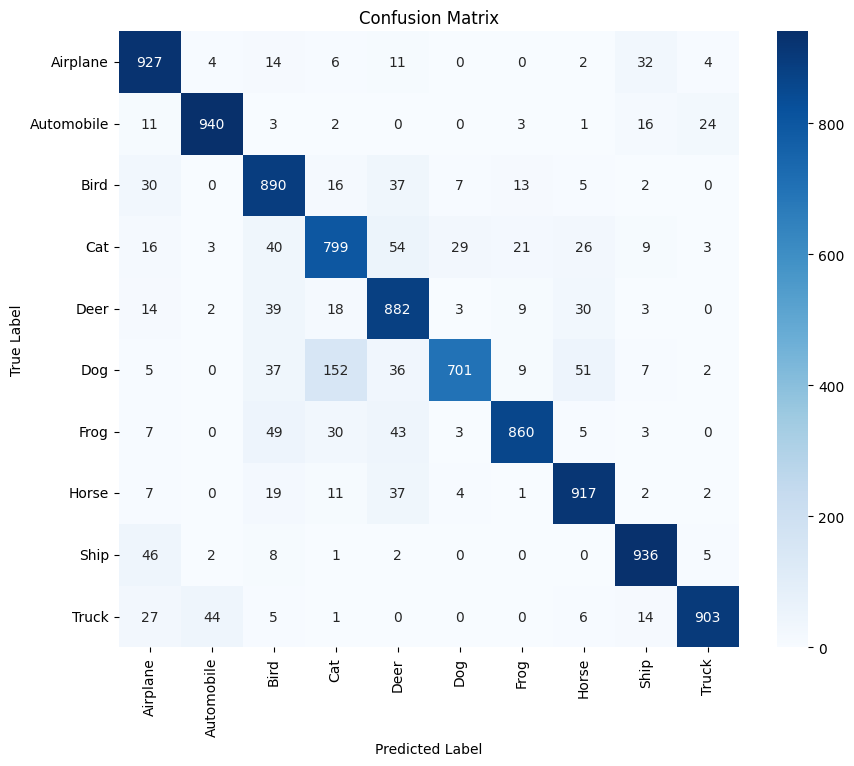

In [ ]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

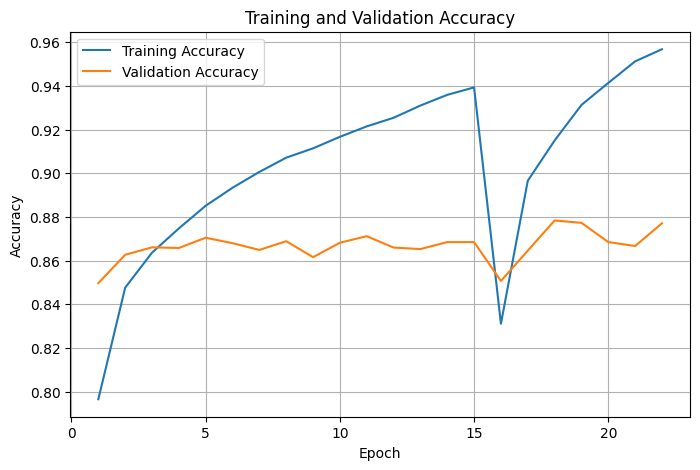

In [ ]:
train_accuracy = (
    history_initial.history["accuracy"]
    + history_finetune.history["accuracy"]
)

val_accuracy = (
    history_initial.history["val_accuracy"]
    + history_finetune.history["val_accuracy"]
)

epochs = range(1, len(train_accuracy) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_accuracy,
    label="Training Accuracy"
)

plt.plot(
    epochs,
    val_accuracy,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")

plt.legend()
plt.grid()
plt.show()

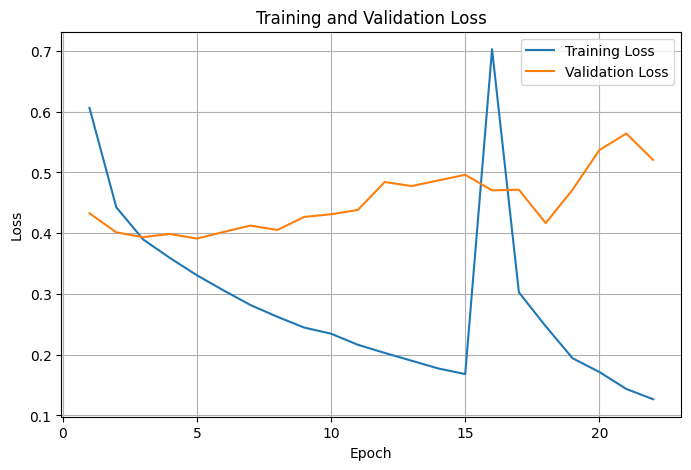

In [ ]:
train_loss = (
    history_initial.history["loss"]
    + history_finetune.history["loss"]
)

val_loss = (
    history_initial.history["val_loss"]
    + history_finetune.history["val_loss"]
)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_loss,
    label="Training Loss"
)

plt.plot(
    epochs,
    val_loss,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training and Validation Loss")
plt.legend()
plt.grid()
plt.show()

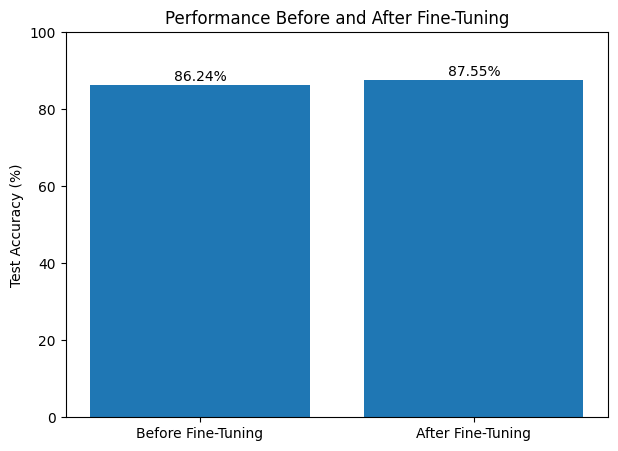

In [ ]:
labels = [
    "Before Fine-Tuning",
    "After Fine-Tuning"
]

accuracies = [
    test_acc_before * 100,
    test_accuracy * 100
]

plt.figure(figsize=(7, 5))

bars = plt.bar(
    labels,
    accuracies
)

plt.ylabel("Test Accuracy (%)")

plt.title(
    "Performance Before and After Fine-Tuning"
)

plt.ylim(0, 100)

for bar, value in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.show()

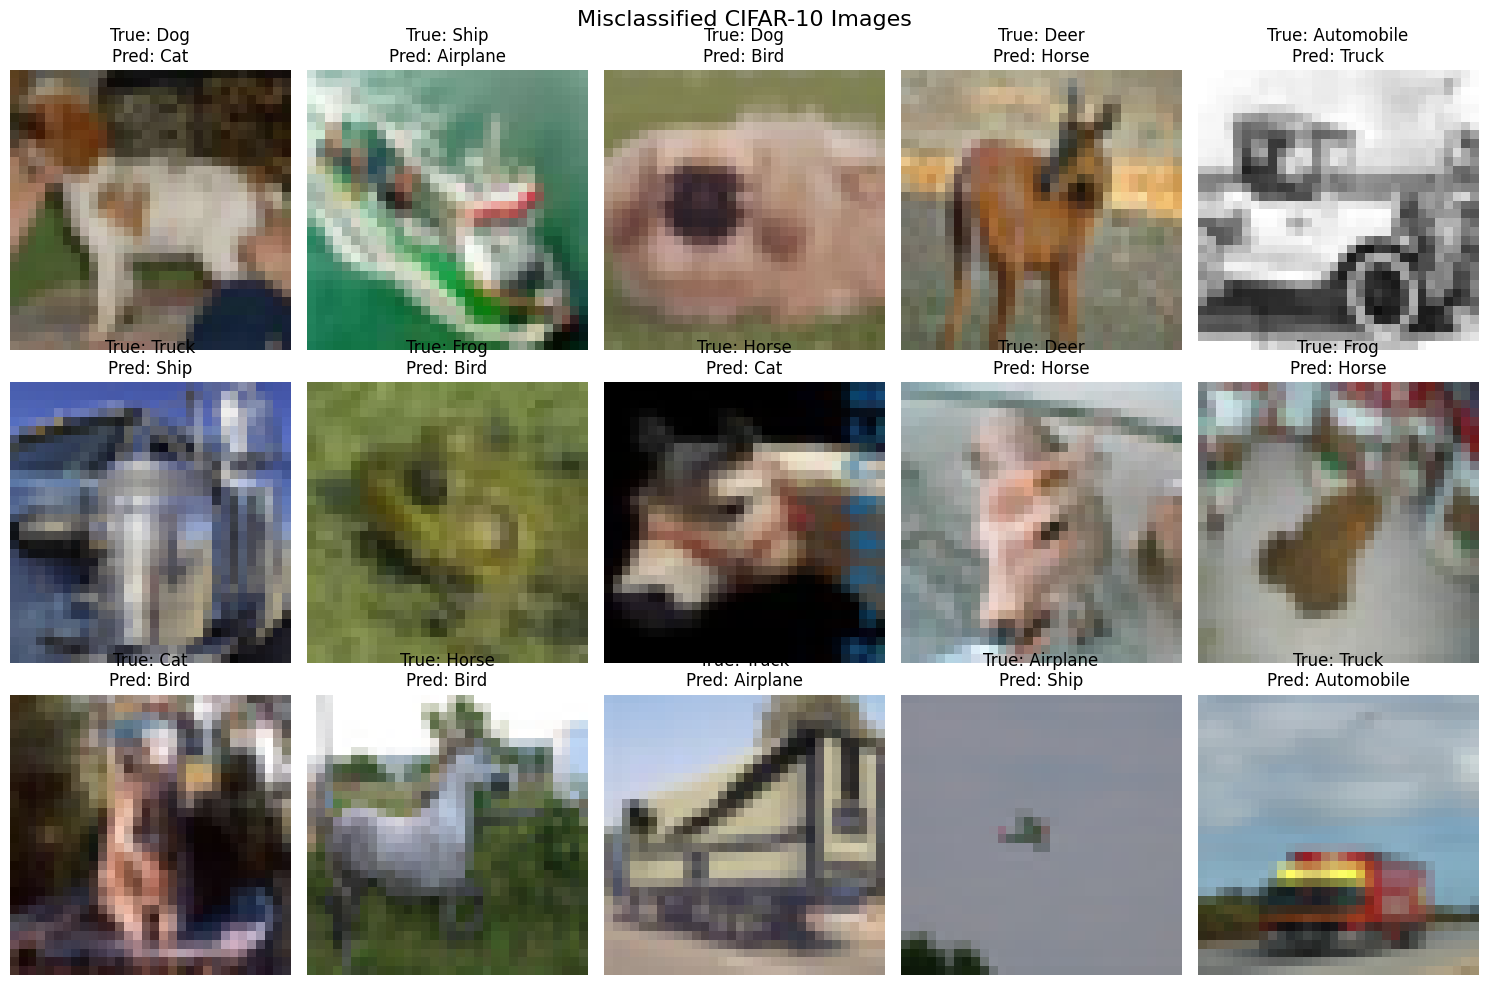

In [ ]:
misclassified = np.where(
    y_true != y_pred
)[0]

plt.figure(figsize=(15, 10))

for i, idx in enumerate(misclassified[:15]):

    plt.subplot(3, 5, i + 1)

    plt.imshow(x_test[idx])

    plt.title(
        f"True: {class_names[y_true[idx]]}\n"
        f"Pred: {class_names[y_pred[idx]]}"
    )

    plt.axis("off")

plt.suptitle(
    "Misclassified CIFAR-10 Images",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [ ]:
total_params = model.count_params()
print("Total Parameters:", total_params)
training_accuracy = train_accuracy[-1]

print(
    "Final Training Accuracy:",
    round(training_accuracy * 100, 2),
    "%"
)

Total Parameters: 2423242
Final Training Accuracy: 95.67 %


In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Metric": [
        "Training Accuracy",
        "Testing Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "Total Parameters"
    ],

    "Value": [
        f"{training_accuracy * 100:.2f}%",
        f"{test_accuracy * 100:.2f}%",
        f"{precision:.4f}",
        f"{recall:.4f}",
        f"{f1:.4f}",
        total_params
    ]
})

results

,Metric,Value
0,Training Accuracy,95.67%
1,Testing Accuracy,87.55%
2,Precision,0.8801
3,Recall,0.8755
4,F1-score,0.8752
5,Total Parameters,2423242


Comparison of different models

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2944s 17us/step
Original training data: (50000, 32, 32, 3)
Original testing data : (10000, 32, 32, 3)

Subset sizes:
Train      : (5000, 32, 32, 3)
Validation : (1000, 32, 32, 3)
Test       : (1000, 32, 32, 3)


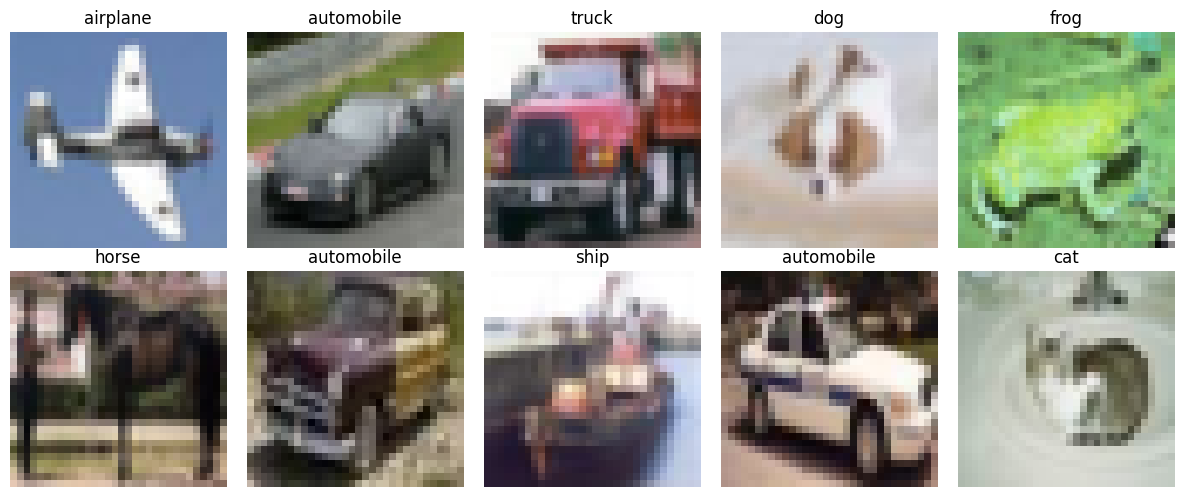

In [1]:


import time
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess


SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


(X_full_train, y_full_train), (X_full_test, y_full_test) = (
    tf.keras.datasets.cifar10.load_data()
)

y_full_train = y_full_train.flatten()
y_full_test = y_full_test.flatten()

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

print("Original training data:", X_full_train.shape)
print("Original testing data :", X_full_test.shape)


X_subset, _, y_subset, _ = train_test_split(
    X_full_train,
    y_full_train,
    train_size=6000,
    stratify=y_full_train,
    random_state=SEED
)

X_train, X_val, y_train, y_val = train_test_split(
    X_subset,
    y_subset,
    test_size=1000,
    stratify=y_subset,
    random_state=SEED
)

X_test, _, y_test, _ = train_test_split(
    X_full_test,
    y_full_test,
    train_size=1000,
    stratify=y_full_test,
    random_state=SEED
)

print("\nSubset sizes:")
print("Train      :", X_train.shape)
print("Validation :", X_val.shape)
print("Test       :", X_test.shape)


NUM_CLASSES = 10

y_train_cat = tf.keras.utils.to_categorical(y_train, NUM_CLASSES)
y_val_cat = tf.keras.utils.to_categorical(y_val, NUM_CLASSES)
y_test_cat = tf.keras.utils.to_categorical(y_test, NUM_CLASSES)


plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()


IMG_SIZE = 96
BATCH_SIZE = 32

def make_transfer_dataset(X, y, preprocess_fn, shuffle=False):

    ds = tf.data.Dataset.from_tensor_slices((X, y))

    if shuffle:
        ds = ds.shuffle(len(X), seed=SEED)

    def preprocess(image, label):
        image = tf.image.resize(
            tf.cast(image, tf.float32),
            (IMG_SIZE, IMG_SIZE)
        )

        image = preprocess_fn(image)

        return image, label

    ds = ds.map(
        preprocess,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


def plot_history(history, title="Training History"):

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(title + " - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(title + " - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

def evaluate_model(model, test_dataset, y_true, model_name="Model"):

    probabilities = model.predict(test_dataset, verbose=0)
    y_pred = np.argmax(probabilities, axis=1)

    accuracy = np.mean(y_pred == y_true)

    precision = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    print(f"\n===== {model_name} =====")
    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1-score  : {f1:.4f}")

    print("\nClassification Report:")
    print(
        classification_report(
            y_true,
            y_pred,
            target_names=class_names,
            zero_division=0
        )
    )

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 3, 3, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,781,642 (56.39 MB)

 Trainable params: 66,954 (261.54 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 72ms/step - accuracy: 0.5014 - loss: 2.4993 - val_accuracy: 0.6830 - val_loss: 0.9663
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 57ms/step - accuracy: 0.6972 - loss: 0.9378 - val_accuracy: 0.7440 - val_loss: 0.7777
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 50ms/step - accuracy: 0.7676 - loss: 0.6863 - val_accuracy: 0.7630 - val_loss: 0.7159
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - accuracy: 0.8110 - loss: 0.5383 - val_accuracy: 0.7670 - val_loss: 0.6983
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step - accuracy: 0.8446 - loss: 0.4431 - val_accuracy: 0.7810 - val_loss: 0.6872
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step - accuracy: 0.8714 - loss: 0.3587 - val_accuracy: 0.7940 - val_loss: 0.6576
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - accuracy: 0.8978 - loss: 0.3008 - val_accuracy: 0.7870 - val_loss: 0.7085
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step - accuracy: 0.9088 - loss: 0.2637 - val_acc

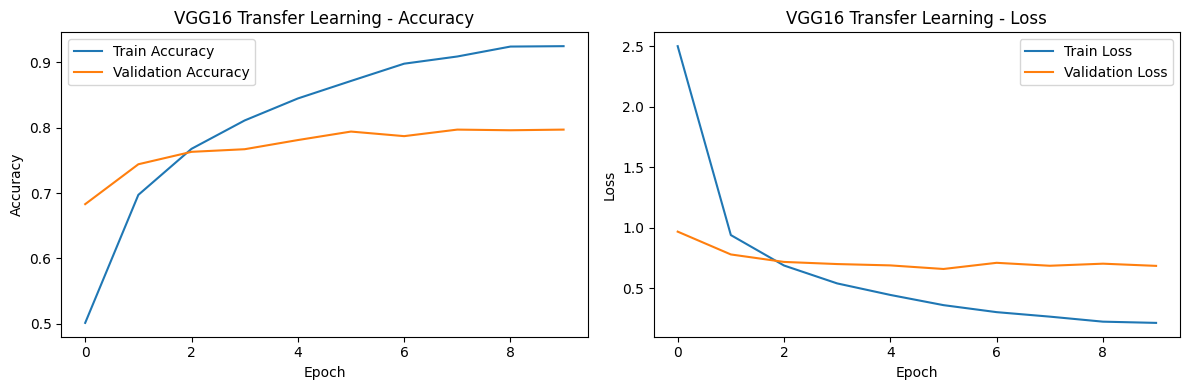


===== VGG16 =====
Accuracy  : 0.7630
Precision : 0.7723
Recall    : 0.7630
F1-score  : 0.7652

Classification Report:
              precision    recall  f1-score   support

    airplane       0.82      0.84      0.83       100
  automobile       0.86      0.87      0.87       100
        bird       0.70      0.74      0.72       100
         cat       0.53      0.64      0.58       100
        deer       0.83      0.64      0.72       100
         dog       0.66      0.73      0.69       100
        frog       0.81      0.76      0.78       100
       horse       0.82      0.79      0.81       100
        ship       0.81      0.84      0.82       100
       truck       0.89      0.78      0.83       100

    accuracy                           0.76      1000
   macro avg       0.77      0.76      0.77      1000
weighted avg       0.77      0.76      0.77      1000



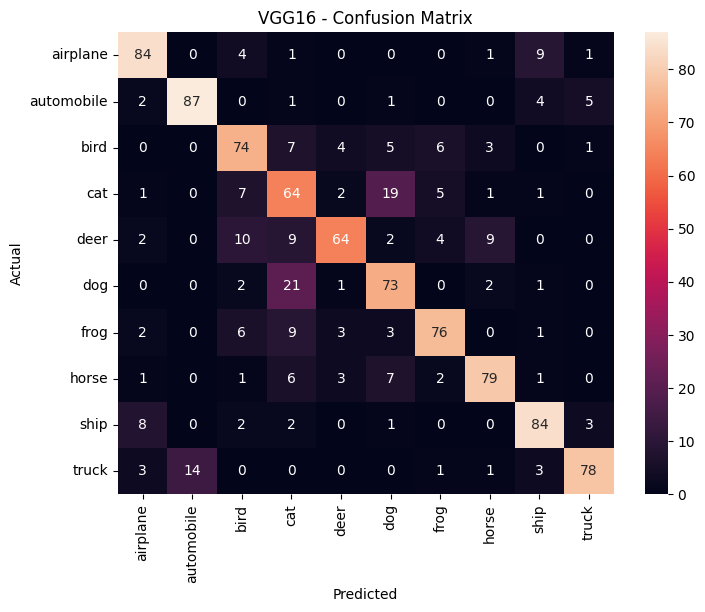


Total parameters: 14781642


In [3]:
#Transfer Learning using VGG-Net
vgg_base = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze pretrained layers
vgg_base.trainable = False

vgg_model = models.Sequential([
    vgg_base,

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(0.3),

    layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

vgg_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

vgg_model.summary()


vgg_train_ds = make_transfer_dataset(
    X_train,
    y_train_cat,
    vgg_preprocess,
    shuffle=True
)

vgg_val_ds = make_transfer_dataset(
    X_val,
    y_val_cat,
    vgg_preprocess
)

vgg_test_ds = make_transfer_dataset(
    X_test,
    y_test_cat,
    vgg_preprocess
)

start_time = time.time()

vgg_history = vgg_model.fit(
    vgg_train_ds,
    validation_data=vgg_val_ds,
    epochs=10,
    verbose=1
)

vgg_training_time = time.time() - start_time
print(f"\nTraining time: {vgg_training_time:.2f} seconds")

plot_history(
    vgg_history,
    "VGG16 Transfer Learning"
)

vgg_results = evaluate_model(
    vgg_model,
    vgg_test_ds,
    y_test,
    "VGG16"
)

print("\nTotal parameters:", vgg_model.count_params())

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 3, 3, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,851,274 (90.99 MB)

 Trainable params: 263,562 (1.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 25s 98ms/step - accuracy: 0.7018 - loss: 0.9577 - val_accuracy: 0.8350 - val_loss: 0.5700
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.8254 - loss: 0.5124 - val_accuracy: 0.8270 - val_loss: 0.5432
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.8762 - loss: 0.3676 - val_accuracy: 0.8230 - val_loss: 0.5449
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.9014 - loss: 0.2830 - val_accuracy: 0.8420 - val_loss: 0.5716
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.9164 - loss: 0.2259 - val_accuracy: 0.8380 - val_loss: 0.5790
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.9330 - loss: 0.1841 - val_accuracy: 0.8350 - val_loss: 0.5922
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.9420 - loss: 0.1604 - val_accuracy: 0.8550 - val_loss: 0.5980
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.9540 - loss: 0.1262 - val_acc

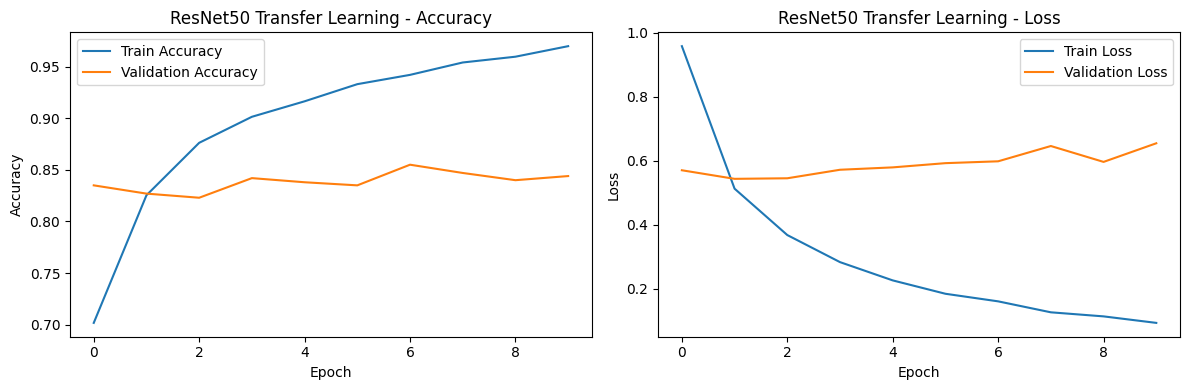


===== ResNet50 =====
Accuracy  : 0.8110
Precision : 0.8131
Recall    : 0.8110
F1-score  : 0.8114

Classification Report:
              precision    recall  f1-score   support

    airplane       0.84      0.80      0.82       100
  automobile       0.91      0.86      0.88       100
        bird       0.82      0.80      0.81       100
         cat       0.66      0.69      0.68       100
        deer       0.72      0.78      0.75       100
         dog       0.81      0.74      0.77       100
        frog       0.85      0.85      0.85       100
       horse       0.86      0.84      0.85       100
        ship       0.81      0.88      0.85       100
       truck       0.84      0.87      0.86       100

    accuracy                           0.81      1000
   macro avg       0.81      0.81      0.81      1000
weighted avg       0.81      0.81      0.81      1000



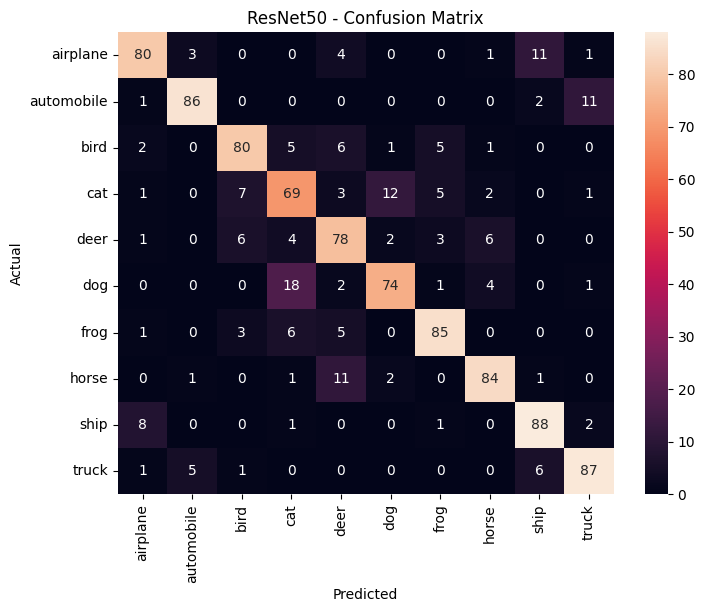


Total parameters: 23851274


In [5]:
#Using ResNet-50 Model

resnet_base = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Freeze pretrained convolutional layers
resnet_base.trainable = False

resnet_model = models.Sequential([
    resnet_base,

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(0.3),

    layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

resnet_model.summary()


resnet_train_ds = make_transfer_dataset(
    X_train,
    y_train_cat,
    resnet_preprocess,
    shuffle=True
)

resnet_val_ds = make_transfer_dataset(
    X_val,
    y_val_cat,
    resnet_preprocess
)

resnet_test_ds = make_transfer_dataset(
    X_test,
    y_test_cat,
    resnet_preprocess
)


start_time = time.time()

resnet_history = resnet_model.fit(
    resnet_train_ds,
    validation_data=resnet_val_ds,
    epochs=10,
    verbose=1
)

resnet_training_time = time.time() - start_time

print(f"\nTraining time: {resnet_training_time:.2f} seconds")


plot_history(
    resnet_history,
    "ResNet50 Transfer Learning"
)

resnet_results = evaluate_model(
    resnet_model,
    resnet_test_ds,
    y_test,
    "ResNet50"
)

print("\nTotal parameters:", resnet_model.count_params())

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 71ms/step - accuracy: 0.5094 - loss: 2.3745 - val_accuracy: 0.6920 - val_loss: 0.9438
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - accuracy: 0.6982 - loss: 0.9093 - val_accuracy: 0.7370 - val_loss: 0.8068
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 60ms/step - accuracy: 0.7702 - loss: 0.6766 - val_accuracy: 0.7600 - val_loss: 0.7461
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - accuracy: 0.8126 - loss: 0.5386 - val_accuracy: 0.7750 - val_loss: 0.7224
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - accuracy: 0.8546 - loss: 0.4232 - val_accuracy: 0.7770 - val_loss: 0.7284
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step - accuracy: 0.8644 - loss: 0.3771 - val_accuracy: 0.7940 - val_loss: 0.7260
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - accuracy: 0.8874 - loss: 0.3208 - val_accuracy: 0.7840 - val_loss: 0.7319
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - accuracy: 0.9072 - loss: 0.2624 - val_acc

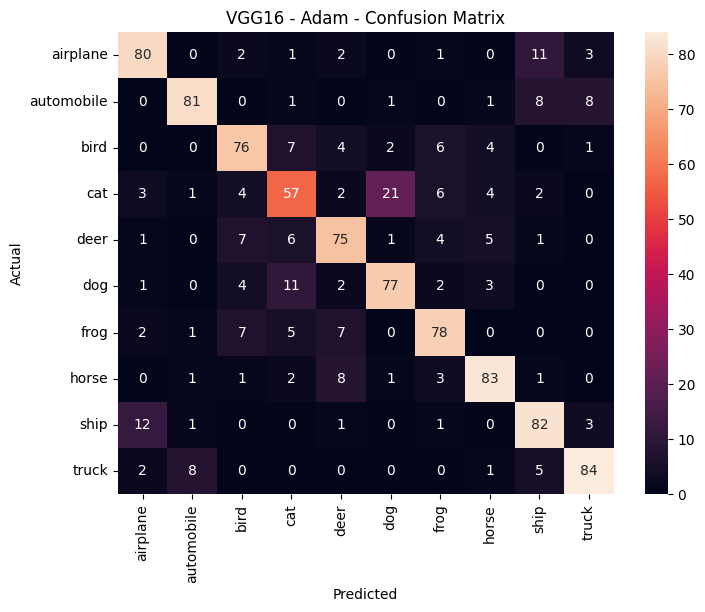

Epoch 1/2
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 72ms/step - accuracy: 0.5288 - loss: 2.0900 - val_accuracy: 0.7010 - val_loss: 0.8948
Epoch 2/2
157/157 ━━━━━━━━━━━━━━━━━━━━ 16s 53ms/step - accuracy: 0.6908 - loss: 0.9329 - val_accuracy: 0.7370 - val_loss: 0.8000

===== VGG16 - SGD =====
Accuracy  : 0.7200
Precision : 0.7277
Recall    : 0.7200
F1-score  : 0.7211

Classification Report:
              precision    recall  f1-score   support

    airplane       0.76      0.76      0.76       100
  automobile       0.94      0.75      0.83       100
        bird       0.75      0.65      0.70       100
         cat       0.48      0.56      0.52       100
        deer       0.71      0.61      0.66       100
         dog       0.71      0.67      0.69       100
        frog       0.74      0.78      0.76       100
       horse       0.72      0.76      0.74       100
        ship       0.71      0.79      0.75       100
       truck       0.77      0.87      0.82       100

    accuracy         

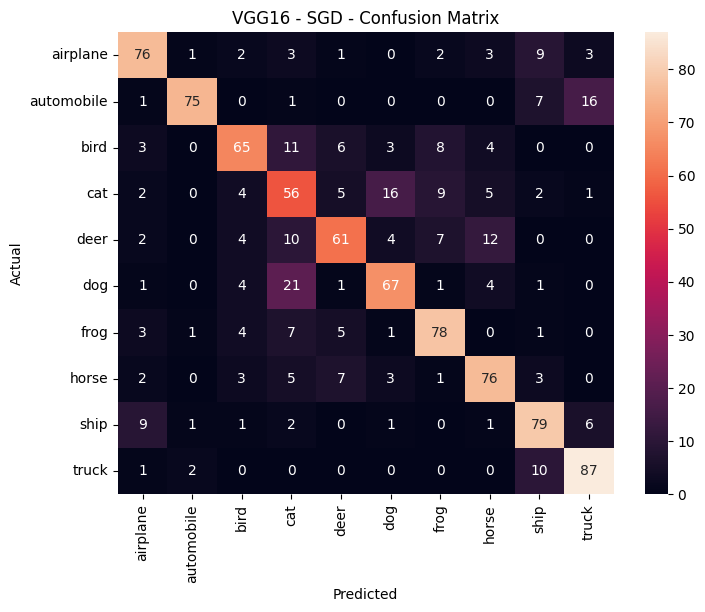

ADAM vs SGD
Adam Accuracy:0.7730
SGD Accuracy:0.7200
Adam Time:90.64 sec
SGD Time:29.58 sec


In [6]:
def build_vgg_classifier(optimizer):

    base = VGG16(
        weights="imagenet",
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    base.trainable = False

    model = models.Sequential([
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(NUM_CLASSES, activation="softmax")
    ])

    model.compile(
        optimizer=optimizer,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model



adam_model = build_vgg_classifier(
    tf.keras.optimizers.Adam(
        learning_rate=0.001
    )
)

start_time = time.time()

adam_history = adam_model.fit(
    vgg_train_ds,
    validation_data=vgg_val_ds,
    epochs=10,
    verbose=1
)

adam_time = time.time() - start_time

adam_results = evaluate_model(
    adam_model,
    vgg_test_ds,
    y_test,
    "VGG16 - Adam"
)


sgd_model = build_vgg_classifier(
    tf.keras.optimizers.SGD(
        learning_rate=0.001,
        momentum=0.9
    )
)

start_time = time.time()

sgd_history = sgd_model.fit(
    vgg_train_ds,
    validation_data=vgg_val_ds,
    epochs=2,
    verbose=1
)

sgd_time = time.time() - start_time

sgd_results = evaluate_model(
    sgd_model,
    vgg_test_ds,
    y_test,
    "VGG16 - SGD"
)


print("ADAM vs SGD")

print(
    f"Adam Accuracy:{adam_results['accuracy']:.4f}"
)

print(
    f"SGD Accuracy:{sgd_results['accuracy']:.4f}"
)

print(
    f"Adam Time:{adam_time:.2f} sec"
)

print(
    f"SGD Time:{sgd_time:.2f} sec"
)

PHASE 1: All pretrained layers frozen
Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 70ms/step - accuracy: 0.5070 - loss: 2.3825 - val_accuracy: 0.7210 - val_loss: 0.9182
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step - accuracy: 0.7012 - loss: 0.8917 - val_accuracy: 0.7430 - val_loss: 0.7702
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - accuracy: 0.7712 - loss: 0.6737 - val_accuracy: 0.7670 - val_loss: 0.7036
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - accuracy: 0.8110 - loss: 0.5398 - val_accuracy: 0.7740 - val_loss: 0.7142
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step - accuracy: 0.8364 - loss: 0.4460 - val_accuracy: 0.7850 - val_loss: 0.7078
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step - accuracy: 0.8722 - loss: 0.3706 - val_accuracy: 0.8010 - val_loss: 0.6681
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - accuracy: 0.8916 - loss: 0.3120 - val_accuracy: 0.7960 - val_loss: 0.6831
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step - acc

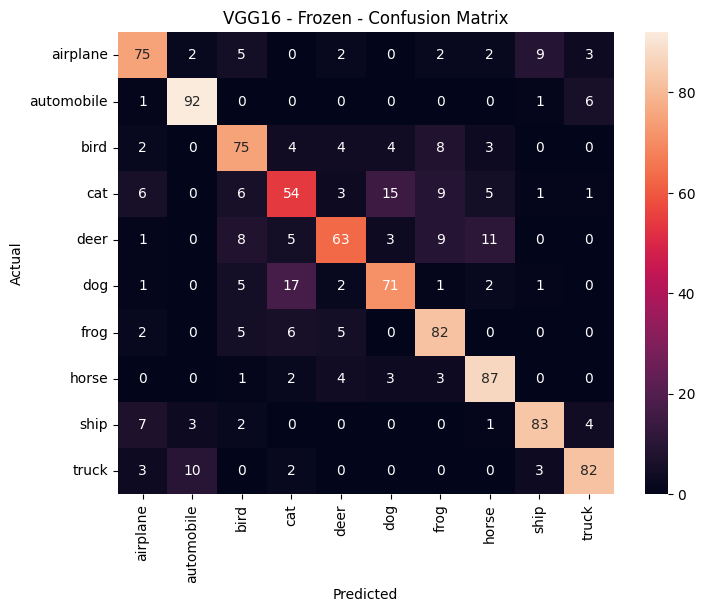


Trainable layers after unfreezing block5:
block5_conv1
block5_conv2
block5_conv3
block5_pool

PHASE 2: Fine tuning last convolution block
Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 90ms/step - accuracy: 0.7848 - loss: 0.6935 - val_accuracy: 0.8210 - val_loss: 0.6383
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 15s 69ms/step - accuracy: 0.8842 - loss: 0.3512 - val_accuracy: 0.8290 - val_loss: 0.5566
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 69ms/step - accuracy: 0.9260 - loss: 0.2044 - val_accuracy: 0.8400 - val_loss: 0.5938
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 69ms/step - accuracy: 0.9454 - loss: 0.1680 - val_accuracy: 0.8300 - val_loss: 0.6686
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 69ms/step - accuracy: 0.9584 - loss: 0.1308 - val_accuracy: 0.8600 - val_loss: 0.6283
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 76ms/step - accuracy: 0.9848 - loss: 0.0529 - val_accuracy: 0.8550 - val_loss: 0.7846
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 68ms/step - accuracy: 0.9786 - loss: 

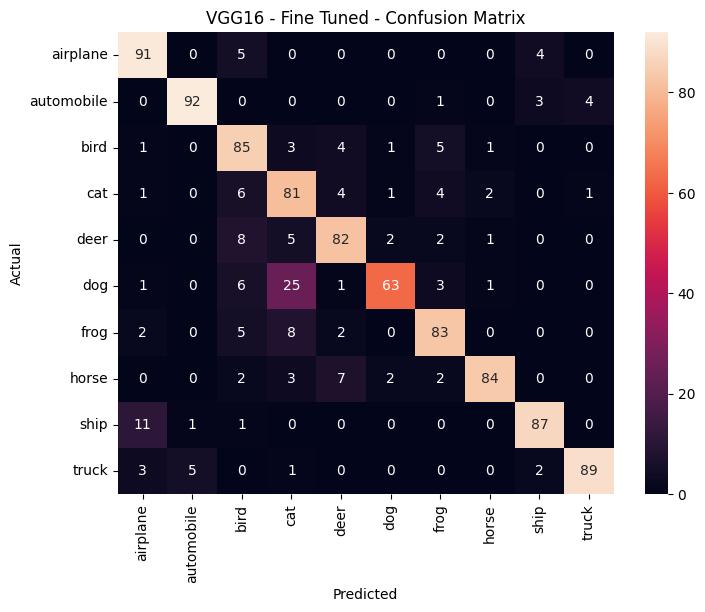


FROZEN vs FINE TUNED
Frozen Accuracy: 0.7640
Fine-tuned Accuracy: 0.8370


In [10]:
#freezing layers vs fine tuning

fine_tune_model = models.Sequential([
    VGG16(
        weights="imagenet",
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    ),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),

    layers.Dropout(0.3),

    layers.Dense(NUM_CLASSES, activation="softmax")
])


base_model = fine_tune_model.layers[0]

base_model.trainable = False

fine_tune_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("PHASE 1: All pretrained layers frozen")

frozen_history = fine_tune_model.fit(
    vgg_train_ds,
    validation_data=vgg_val_ds,
    epochs=10,
    verbose=1
)

frozen_results = evaluate_model(
    fine_tune_model,
    vgg_test_ds,
    y_test,
    "VGG16 - Frozen"
)


base_model.trainable = True

# Freeze everything except block5
for layer in base_model.layers:

    if layer.name.startswith("block5"):
        layer.trainable = True
    else:
        layer.trainable = False

print("\nTrainable layers after unfreezing block5:")

for layer in base_model.layers:
    if layer.trainable:
        print(layer.name)

# Fine tuning should normally use a much smaller LR.
fine_tune_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("\nPHASE 2: Fine tuning last convolution block")

fine_tune_history = fine_tune_model.fit(
    vgg_train_ds,
    validation_data=vgg_val_ds,
    epochs=10,
    verbose=1
)

fine_tuned_results = evaluate_model(
    fine_tune_model,
    vgg_test_ds,
    y_test,
    "VGG16 - Fine Tuned"
)

print("\n===================================")
print("FROZEN vs FINE TUNED")
print("===================================")

print(
    f"Frozen Accuracy: "
    f"{frozen_results['accuracy']:.4f}"
)

print(
    f"Fine-tuned Accuracy: "
    f"{fine_tuned_results['accuracy']:.4f}"
)


MODEL EVALUATION
Accuracy  : 0.7630
Precision : 0.7723
Recall    : 0.7630
F1-score  : 0.7652

Classification Report:

              precision    recall  f1-score   support

    airplane       0.82      0.84      0.83       100
  automobile       0.86      0.87      0.87       100
        bird       0.70      0.74      0.72       100
         cat       0.53      0.64      0.58       100
        deer       0.83      0.64      0.72       100
         dog       0.66      0.73      0.69       100
        frog       0.81      0.76      0.78       100
       horse       0.82      0.79      0.81       100
        ship       0.81      0.84      0.82       100
       truck       0.89      0.78      0.83       100

    accuracy                           0.76      1000
   macro avg       0.77      0.76      0.77      1000
weighted avg       0.77      0.76      0.77      1000



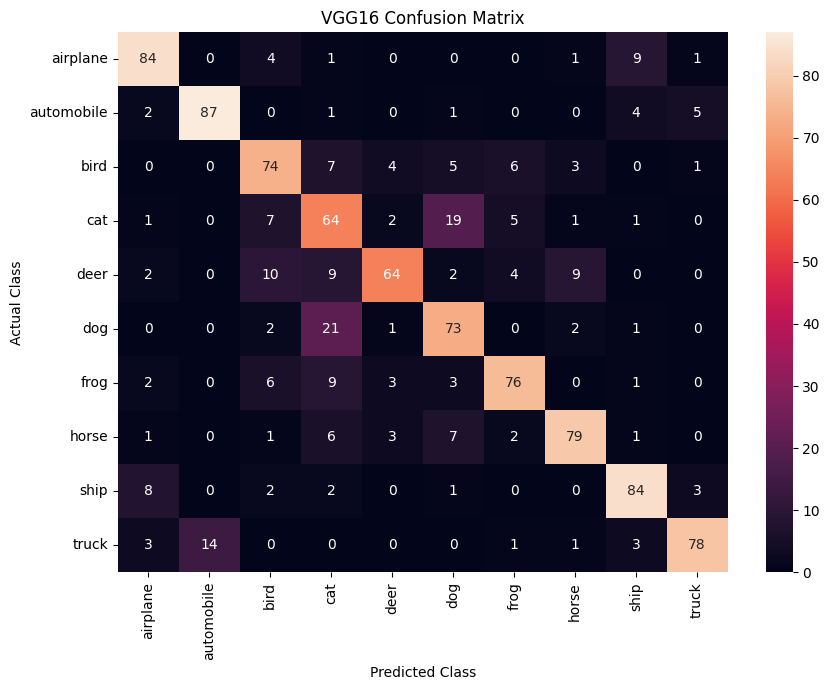

In [11]:
#Confusion Matrix Metrics
pred_probabilities = vgg_model.predict(
    vgg_test_ds,
    verbose=0
)

y_pred = np.argmax(
    pred_probabilities,
    axis=1
)

test_accuracy = np.mean(
    y_pred == y_test
)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

print("MODEL EVALUATION")

print(f"Accuracy  : {test_accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=class_names,
        zero_division=0
    )
)


cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("VGG16 Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

-LeNet-


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 6)      │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 14, 14, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 5, 5, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,006 (242.21 KB)

 Trainable params: 62,006 (242.21 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.2428 - loss: 2.0493 - val_accuracy: 0.2650 - val_loss: 1.9775
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3524 - loss: 1.7790 - val_accuracy: 0.3620 - val_loss: 1.7534
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3930 - loss: 1.6571 - val_accuracy: 0.3960 - val_loss: 1.6466
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4276 - loss: 1.5631 - val_accuracy: 0.4320 - val_loss: 1.6025
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4658 - loss: 1.4741 - val_accuracy: 0.4360 - val_loss: 1.5521
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4842 - loss: 1.4197 - val_accuracy: 0.4470 - val_loss: 1.5374
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5106 - loss: 1.3501 - val_accuracy: 0.4470 - val_loss: 1.5371
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5298 - loss: 1.3051 - val_accuracy: 0

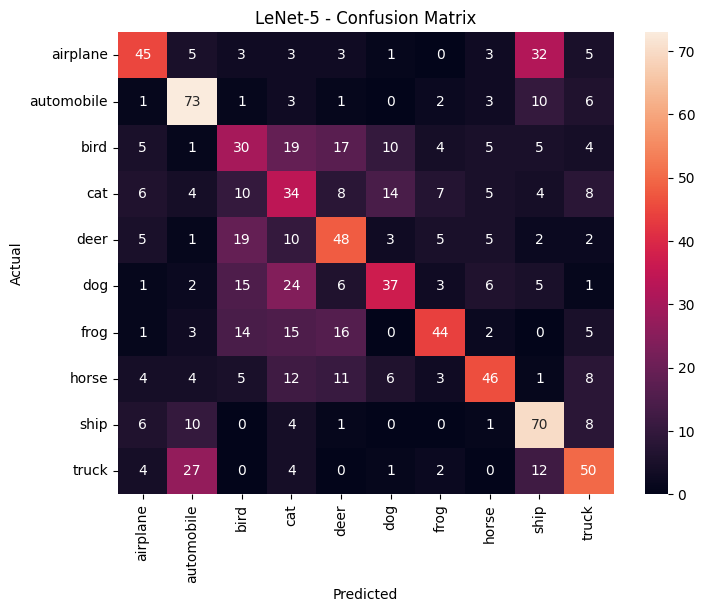

--AlexNet--


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833,738 (3.18 MB)

 Trainable params: 833,738 (3.18 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 38ms/step - accuracy: 0.1404 - loss: 2.2529 - val_accuracy: 0.2180 - val_loss: 2.1353
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2470 - loss: 2.0093 - val_accuracy: 0.2820 - val_loss: 1.8299
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3010 - loss: 1.8131 - val_accuracy: 0.3580 - val_loss: 1.6640
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3728 - loss: 1.6706 - val_accuracy: 0.3950 - val_loss: 1.6808
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.4108 - loss: 1.5854 - val_accuracy: 0.4480 - val_loss: 1.5054
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4436 - loss: 1.4821 - val_accuracy: 0.4840 - val_loss: 1.4491
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4810 - loss: 1.3950 - val_accuracy: 0.4710 - val_loss: 1.4748
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5236 - loss: 1.3097 - val_accuracy: 

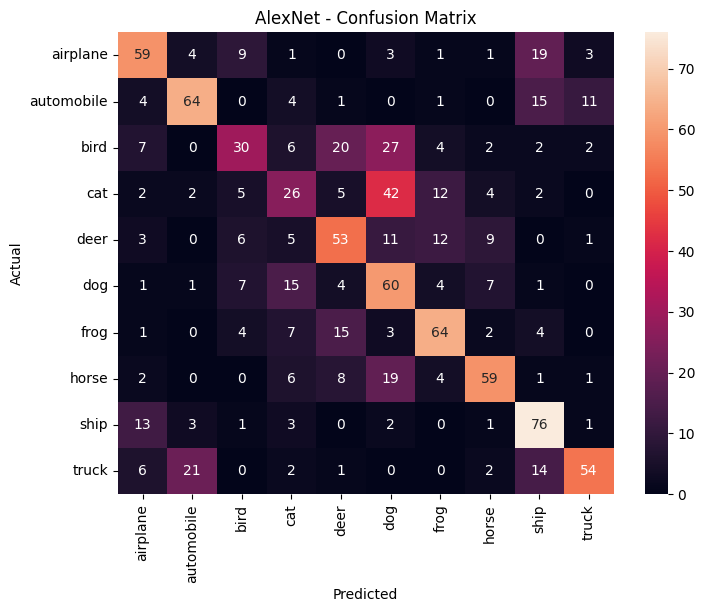


LE NET vs ALEXNET vs RESNET50
Model          Accuracy       Parameters     Training Time
------------------------------------------------------------
LeNet-5        0.4770         62006          11.65s
AlexNet        0.5450         833738         17.36s
ResNet50       0.8110         23851274       66.58s


In [14]:
#Comaprison of LeNet, AlexNet and ResNet

X_train_small = X_train.astype("float32") / 255.0
X_val_small = X_val.astype("float32") / 255.0
X_test_small = X_test.astype("float32") / 255.0

custom_train_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_train_small, y_train_cat))
    .shuffle(len(X_train_small), seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

custom_val_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_val_small, y_val_cat))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

custom_test_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_test_small, y_test_cat))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)
#lenet
def build_lenet():

    model = models.Sequential([
        layers.Conv2D(
            6,
            (5, 5),
            activation="relu",
            input_shape=(32, 32, 3)
        ),

        layers.AveragePooling2D(
            pool_size=(2, 2)
        ),

        layers.Conv2D(
            16,
            (5, 5),
            activation="relu"
        ),

        layers.AveragePooling2D(
            pool_size=(2, 2)
        ),

        layers.Flatten(),

        layers.Dense(
            120,
            activation="relu"
        ),

        layers.Dense(
            84,
            activation="relu"
        ),

        layers.Dense(
            NUM_CLASSES,
            activation="softmax"
        )
    ])

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

lenet_model = build_lenet()

print("-LeNet-")
lenet_model.summary()

start = time.time()

lenet_history = lenet_model.fit(
    custom_train_ds,
    validation_data=custom_val_ds,
    epochs=10,
    verbose=1
)

lenet_time = time.time() - start

lenet_results = evaluate_model(
    lenet_model,
    custom_test_ds,
    y_test,
    "LeNet-5"
)


#alexnet

def build_alexnet():

    model = models.Sequential([

        layers.Conv2D(
            32,
            (3, 3),
            padding="same",
            activation="relu",
            input_shape=(32, 32, 3)
        ),

        layers.MaxPooling2D(
            pool_size=(2, 2)
        ),

        layers.Conv2D(
            64,
            (3, 3),
            padding="same",
            activation="relu"
        ),

        layers.MaxPooling2D(
            pool_size=(2, 2)
        ),

        layers.Conv2D(
            128,
            (3, 3),
            padding="same",
            activation="relu"
        ),

        layers.Conv2D(
            128,
            (3, 3),
            padding="same",
            activation="relu"
        ),

        layers.MaxPooling2D(
            pool_size=(2, 2)
        ),

        layers.Flatten(),

        layers.Dense(
            256,
            activation="relu"
        ),

        layers.Dropout(0.5),

        layers.Dense(
            256,
            activation="relu"
        ),

        layers.Dropout(0.5),

        layers.Dense(
            NUM_CLASSES,
            activation="softmax"
        )
    ])

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


alexnet_model = build_alexnet()

print("--AlexNet--")
alexnet_model.summary()

start = time.time()

alexnet_history = alexnet_model.fit(
    custom_train_ds,
    validation_data=custom_val_ds,
    epochs=10,
    verbose=1
)

alexnet_time = time.time() - start

alexnet_results = evaluate_model(
    alexnet_model,
    custom_test_ds,
    y_test,
    "AlexNet"
)

#resnet
resnet_params = resnet_model.count_params()


print("\n================================================")
print("LE NET vs ALEXNET vs RESNET50")
print("================================================")

print(
    f"{'Model':<15}"
    f"{'Accuracy':<15}"
    f"{'Parameters':<15}"
    f"Training Time"
)

print("-" * 60)

print(
    f"{'LeNet-5':<15}"
    f"{lenet_results['accuracy']:<15.4f}"
    f"{lenet_model.count_params():<15}"
    f"{lenet_time:.2f}s"
)

print(
    f"{'AlexNet':<15}"
    f"{alexnet_results['accuracy']:<15.4f}"
    f"{alexnet_model.count_params():<15}"
    f"{alexnet_time:.2f}s"
)

print(
    f"{'ResNet50':<15}"
    f"{resnet_results['accuracy']:<15.4f}"
    f"{resnet_params:<15}"
    f"{resnet_training_time:.2f}s"
)